In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns
from tqdm import tqdm
import os
from sklearn.metrics import f1_score, accuracy_score

# ---------------------- 1. 环境配置 ----------------------
def set_chinese_font():
    """设置中文字体以支持可视化"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ---------------------- 2. 核心对比模型：MSFF-GRU ----------------------
class MSFF_GRU(nn.Module):
    """
    对比模型：多尺度特征融合 GRU (MSFF-GRU)
    前端：多尺度 Conv1d 特征提取
    中端：双层双向 GRU 替代 Transformer
    后端：多任务输出头 (态势预测、种类识别、物理特征)
    """
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_GRU, self).__init__()
        self.horizon = horizon
        
        # 🟢 前端：多尺度特征提取 (与 Transformer 脚本完全对齐)
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model)
        self.gelu = nn.GELU()
        
        # 🟢 中端：GRU 编码器 (input_size)
        # 使用双向 GRU 以获得更完整的时序依赖建模
        self.gru = nn.GRU(input_size=d_model, hidden_size=d_model // 2, 
                          num_layers=num_layers, batch_first=True, bidirectional=True)
        
        # 🟢 后端：多任务输出头 (保持一致)
        self.head_horizon = nn.Sequential(
            nn.Linear(d_model, 512), 
            nn.GELU(), 
            nn.Linear(512, horizon * input_dim), 
            nn.Sigmoid()
        )
        self.head_type = nn.Sequential(
            nn.Linear(d_model * 2, 512), 
            nn.LayerNorm(512), 
            nn.GELU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 256), 
            nn.GELU(), 
            nn.Linear(256, 5)
        )
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        # x: (Batch, 12, 10) -> (Batch, 10, 12)
        x_in = x.permute(0, 2, 1)
        
        # MSFF 卷积特征融合
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1) # -> (Batch, 12, 512)
        
        # GRU 编码
        x, _ = self.gru(x) # -> (Batch, 12, 512)
        
        # 特征池化 (平均+最大)
        avg_feat = torch.mean(x, dim=1)
        max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1) 
        
        # 最后一帧用于态势预测热图
        feat_last = x[:, -1, :] 
        
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), \
               self.head_type(concat_feat), \
               self.head_physics(avg_feat)

# ---------------------- 3. 损失函数 (Focal Loss 保持一致) ----------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(label_smoothing=0.1)
    def forward(self, input, target):
        logp = self.ce(input, target)
        p = torch.exp(-logp)
        return ((1 - p) ** self.gamma * logp).mean()

# ---------------------- 4. 训练主程序 ----------------------
def run_gru_train_and_save(data_path, save_h5_path, save_pth_path):
    # A. 数据加载与预处理
    with h5py.File(data_path, 'r') as f:
        X = torch.FloatTensor(f['X'][:])
        Y_h = torch.FloatTensor(f['Y_horizon'][:])
        Y_t = torch.LongTensor(f['gt_type'][:])
        # 提取物理规律真值
        P_true = torch.FloatTensor(np.stack([np.mean(Y_h.numpy(), axis=(1,2)), 
                                             np.sum(Y_h.numpy(), axis=(1,2))*0.05], axis=1))

    loader = DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MSFF_GRU().to(device)
    
    # 保持与 Transformer 完全相同的优化器参数
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    criterion_bce, criterion_focal, criterion_mse = nn.BCELoss(), FocalLoss(), nn.MSELoss()

    # B. 训练循环
    print(f"🚀 启动 GRU 对比实验训练 (Epochs: 60)...")
    for epoch in range(60):
        model.train()
        total_l = 0
        for bx, byh, byt, bp in loader:
            bx, byh, byt, bp = bx.to(device), byh.to(device), byt.to(device), bp.to(device)
            optimizer.zero_grad()
            ph, pt, pp = model(bx)
            # 权重分配：态势(1.0) + 识别(4.5) + 物理(0.5)
            loss = 1.0 * criterion_bce(ph, byh) + 4.5 * criterion_focal(pt, byt) + 0.5 * criterion_mse(pp, bp)
            loss.backward()
            optimizer.step()
            total_l += loss.item()
        
        if (epoch+1) % 10 == 0:
            print(f"进度: {epoch+1}/60, 当前 GRU Loss: {total_l/len(loader):.4f}")

    # C. 模型持久化
    torch.save(model.state_dict(), save_pth_path)
    print(f"\n💾 对比模型权重已保存至 {save_pth_path}")

    # D. 最终评估
    model.eval()
    all_h, all_t = [], []
    with torch.no_grad():
        eval_loader = DataLoader(TensorDataset(X, Y_h, Y_t, P_true), batch_size=32)
        for bx, _, _, _ in eval_loader:
            ph, pt, _ = model(bx.to(device))
            all_h.append(ph.cpu().numpy())
            all_t.append(pt.cpu().numpy())
    
    fh, ft = np.concatenate(all_h), np.concatenate(all_t)
    f1 = f1_score(Y_h.numpy().flatten() > 0.5, fh.flatten() > 0.4)
    acc = accuracy_score(Y_t.numpy(), np.argmax(ft, axis=1))

    print("\n" + "📊" * 15 + "\n【GRU 对比训练最终结果】")
    print(f"🔹 态势预测 F1: {f1:.4f}")
    print(f"🔹 种类识别 Acc: {acc*100:.2f}%")
    print("📊" * 15)

    # 保存推理结果用于 NRMSE 对比分析
    with h5py.File(save_h5_path, 'w') as f:
        f.create_dataset("predicted_situations", data=fh)
        f.create_dataset("ground_truth_situations", data=Y_h.numpy())
        f.create_dataset("gt_type", data=Y_t.numpy())
        f.create_dataset("pred_type", data=np.argmax(ft, axis=1))

if __name__ == "__main__":
    IN = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    OUT_H5 = "/root/autodl-tmp/validate/0218/Prediction/GRU/gru_ultimate_results.h5"
    OUT_PTH = "/root/autodl-tmp/validate/0218/Prediction/GRU/best_gru_model.pth"
    
    run_gru_train_and_save(IN, OUT_H5, OUT_PTH)

🚀 启动 GRU 对比实验训练 (Epochs: 60)...
进度: 10/60, 当前 GRU Loss: 2.6308
进度: 20/60, 当前 GRU Loss: 2.2220
进度: 30/60, 当前 GRU Loss: 1.7833
进度: 40/60, 当前 GRU Loss: 1.3661
进度: 50/60, 当前 GRU Loss: 1.0860
进度: 60/60, 当前 GRU Loss: 0.8904

💾 对比模型权重已保存至 /root/autodl-tmp/validate/0218/Prediction/GRU/best_gru_model.pth

📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
【GRU 对比训练最终结果】
🔹 态势预测 F1: 0.9278
🔹 种类识别 Acc: 89.19%
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊


📡 正在执行 GRU 实测评估...


  0%|          | 0/1200 [00:00<?, ?it/s]

100%|██████████| 1200/1200 [00:04<00:00, 287.17it/s]



🎨 高清混淆矩阵已保存: GRU_Academic_CM.png


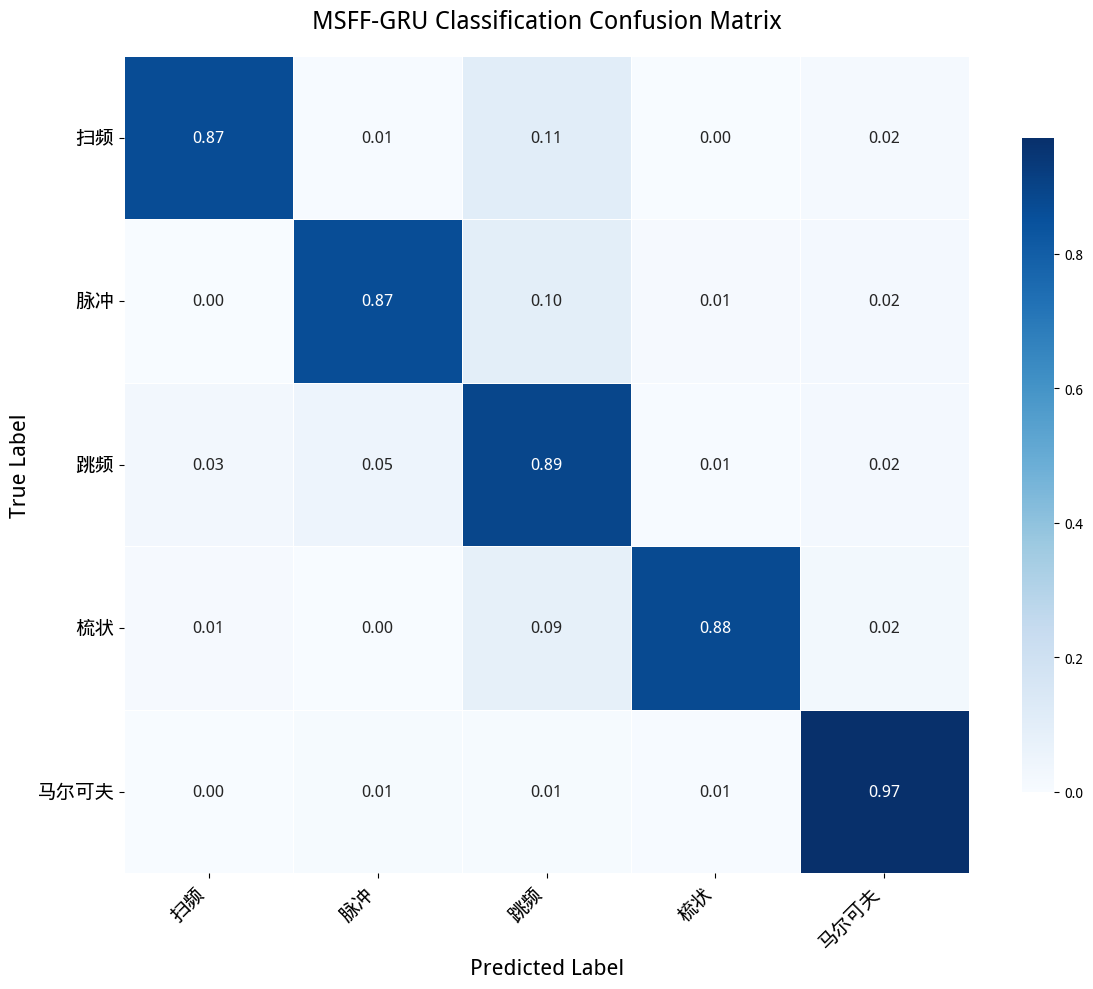

In [4]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report, mean_squared_error
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    """设置中文字体以确保绘图标签正常显示"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

# ==================== 1. 模型定义 (MSFF-GRU) ====================
class MSFF_GRU(nn.Module):
    """
    对比模型：多尺度特征融合 GRU
    """
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_GRU, self).__init__()
        self.horizon = horizon
        # 前端特征提取
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        # GRU 编码器
        self.gru = nn.GRU(input_size=d_model, hidden_size=d_model // 2, 
                          num_layers=num_layers, batch_first=True, bidirectional=True)
        
        # 多任务头
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x, _ = self.gru(x) 
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 2. 工具函数 ====================
def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denom

def load_and_align_rx_data(file_path):
    """实测数据样点对齐"""
    raw_signal = np.fromfile(file_path, dtype=np.complex64)
    return raw_signal[3000:]

def extract_X_robust(iq_window, fs=200e3, threshold=0.12):
    """Max-Energy 鲁棒特征提取"""
    matrix = np.zeros((12, 10))
    freq_centers = np.linspace(-90e3, 90e3, 10)
    n_fft = 1024
    for t in range(12):
        frame = iq_window[t * 10000 : (t+1) * 10000]
        fft_mag = np.abs(np.fft.fftshift(np.fft.fft(frame, n=n_fft)))
        fft_mag /= (np.max(fft_mag) + 1e-9)
        freqs = np.linspace(-fs/2, fs/2, n_fft)
        for ch in range(10):
            center = freq_centers[ch]
            mask = (freqs >= center - 7500) & (freqs <= center + 7500)
            if np.max(fft_mag[mask]) > threshold:
                matrix[t, ch] = 1.0
    return matrix

# ==================== 3. GRU 评估器 ====================
class GRUEvaluator:
    def __init__(self, cfg):
        self.cfg = cfg
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = MSFF_GRU().to(self.device)
        self.model.load_state_dict(torch.load(cfg['weights'], map_location=self.device))
        self.model.eval()
        self.signal = load_and_align_rx_data(cfg['data'])
        with h5py.File(cfg['label'], 'r') as f:
            self.gt_types = f['gt_type'][:]
            self.gt_horizons = f['Y_horizon'][:]

    def run(self, eval_num=1200):
        y_true, y_pred = [], []
        all_pred_maps, all_truth_maps = [], []
        
        print(f"📡 正在执行 GRU 实测评估...")
        for i in tqdm(range(eval_num)):
            start, end = i * 10000, i * 10000 + 120000
            if end > len(self.signal): break
            sit_matrix = extract_X_robust(self.signal[start:end])
            input_tensor = torch.FloatTensor(sit_matrix).unsqueeze(0).to(self.device)
            with torch.no_grad():
                pred_horizon, type_logits, _ = self.model(input_tensor)
                y_pred.append(torch.argmax(type_logits, dim=1).item())
                y_true.append(self.gt_types[i])
                all_pred_maps.append(pred_horizon.cpu().squeeze(0).numpy())
                all_truth_maps.append(self.gt_horizons[i])
        
        # 保存结果用于后续对比分析
        SAVE_PATH = "/root/autodl-tmp/validate/0218/Prediction/GRU/gru_ultimate_results.h5"
        with h5py.File(SAVE_PATH, 'w') as f:
            f.create_dataset("predicted_situations", data=np.array(all_pred_maps))
            f.create_dataset("ground_truth_situations", data=np.array(all_truth_maps))
            f.create_dataset("gt_type", data=np.array(y_true))
            f.create_dataset("pred_type", data=np.array(y_pred))

        self.plot_academic_cm(np.array(y_true), np.array(y_pred))

    def plot_academic_cm(self, y_true, y_pred):
        """参照 MBF-PLENet 风格的高清混淆矩阵可视化"""
        plt.figure(figsize=(12, 10))
        cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
        
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                    linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
        
        plt.title('MSFF-GRU Classification Confusion Matrix', fontsize=18, pad=20)
        plt.xlabel('Predicted Label', fontsize=16)
        plt.ylabel('True Label', fontsize=16)
        
        plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.yticks(rotation=0, fontsize=14) 
        
        plt.tight_layout()
        save_name = "GRU_Academic_CM.png"
        plt.savefig(save_name, dpi=600)
        print(f"\n🎨 高清混淆矩阵已保存: {save_name}")
        plt.show()

if __name__ == "__main__":
    configs = {
        'data': "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat",
        'label': "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5",
        'weights': "/root/autodl-tmp/validate/0218/Prediction/GRU/best_gru_model.pth"
    }
    EVAL = GRUEvaluator(configs)
    EVAL.run()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
--- GRU 干扰识别性能评估 ---
分类准确率 (Acc): 0.9167
加权 F1 分数: 0.9167

物理参数       | MAE (Avg)  | NRMSE (Avg)
------------------------------------------
中心频率       | 3.2188     | 0.5568
带宽         | 0.3170     | 0.1206
JNR        | 0.0331     | 0.0882
------------------------------------------
🎨 高清混淆矩阵已保存: GRU_Academic_CM.png


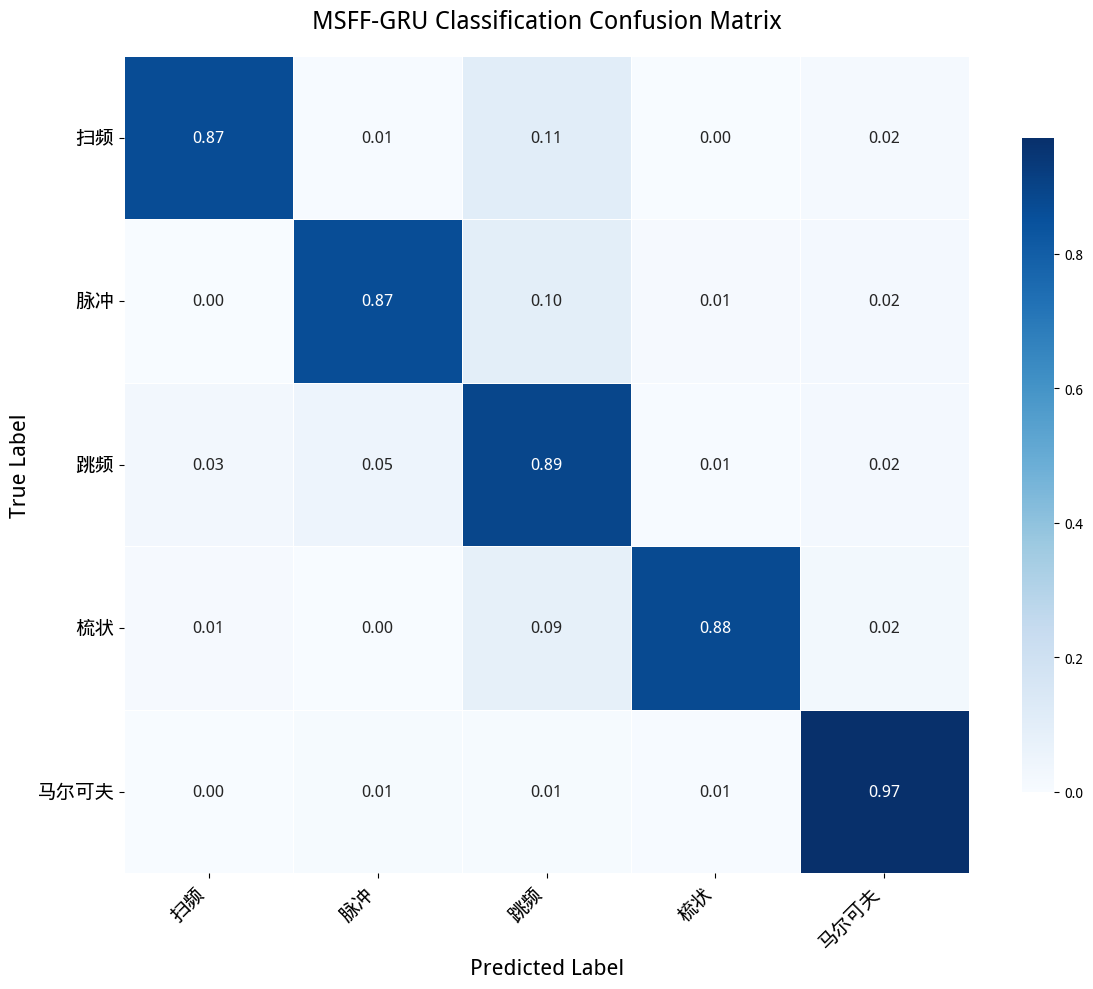

📈 步长衰减图已保存: GRU_Horizon_Decay_Analysis.png


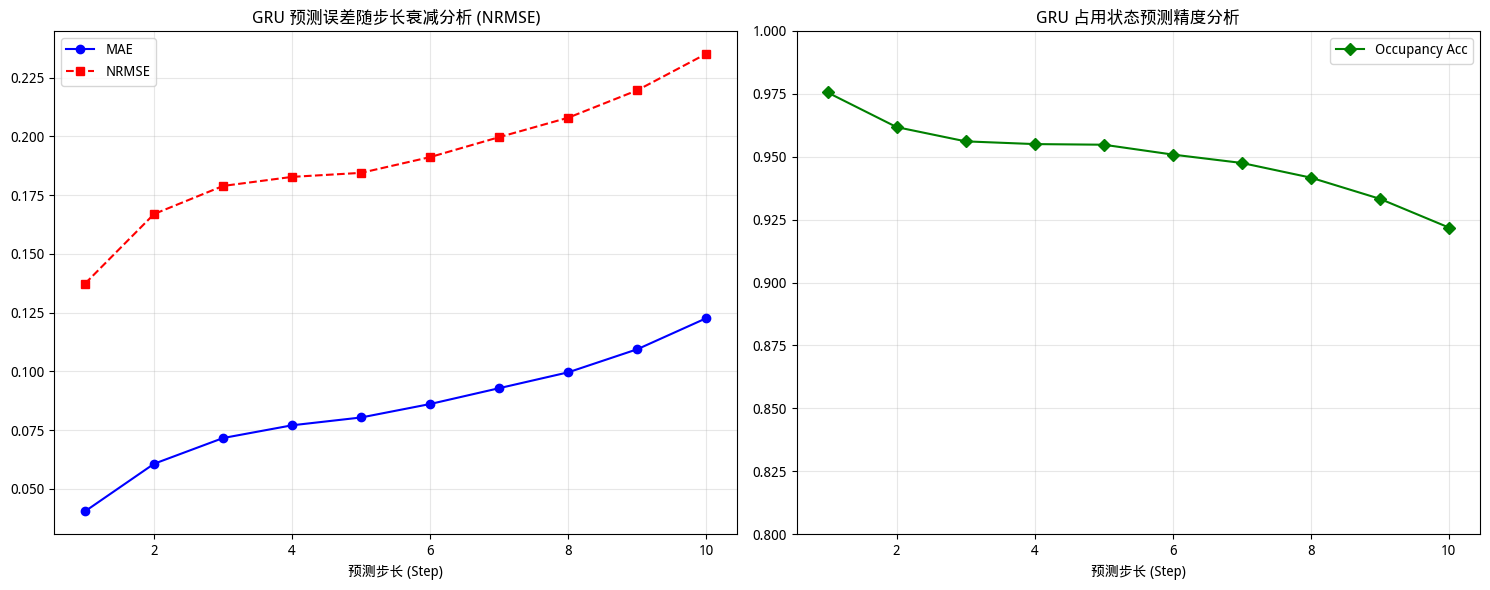

In [5]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix
import os
from tqdm import tqdm
from matplotlib import font_manager as fm

# ==================== 0. 环境配置与中文字体 ====================
def set_chinese_font():
    """设置中文字体以确保高清图表标签正常显示"""
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        return False
    except: return False
set_chinese_font()

LABEL_NAMES = ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"]

# ==================== 1. 指标计算工具函数 ====================
def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 使用真值范围进行归一化，消除量纲影响
    denominator = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denominator

# ==================== 2. GRU 模型定义 (必须与训练时一致) ====================
class MSFF_GRU(nn.Module):
    def __init__(self, input_dim=10, d_model=512, num_layers=2, horizon=10):
        super(MSFF_GRU, self).__init__()
        self.horizon = horizon
        # 前端多尺度卷积提取
        self.conv3 = nn.Conv1d(input_dim, d_model // 4, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(input_dim, d_model // 4, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(input_dim, d_model // 2, kernel_size=7, padding=3)
        self.bn = nn.BatchNorm1d(d_model); self.gelu = nn.GELU()
        
        # GRU 编码器层
        self.gru = nn.GRU(input_size=d_model, hidden_size=d_model // 2, 
                          num_layers=num_layers, batch_first=True, bidirectional=True)
        
        # 多任务输出头
        self.head_horizon = nn.Sequential(nn.Linear(d_model, 512), nn.GELU(), nn.Linear(512, horizon * input_dim), nn.Sigmoid())
        self.head_type = nn.Sequential(nn.Linear(d_model * 2, 512), nn.LayerNorm(512), nn.GELU(),
                                        nn.Dropout(0.5), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 5))
        self.head_physics = nn.Linear(d_model, 2)

    def forward(self, x):
        x_in = x.permute(0, 2, 1)
        x = torch.cat([self.conv3(x_in), self.conv5(x_in), self.conv7(x_in)], dim=1)
        x = self.gelu(self.bn(x)).permute(0, 2, 1)
        x, _ = self.gru(x) 
        avg_feat = torch.mean(x, dim=1); max_feat, _ = torch.max(x, dim=1)
        concat_feat = torch.cat([avg_feat, max_feat], dim=1)
        feat_last = x[:, -1, :]
        return self.head_horizon(feat_last).view(-1, self.horizon, 10), self.head_type(concat_feat), self.head_physics(avg_feat)

# ==================== 3. 性能分析主函数 ====================
def analyze_gru_performance(h5_path):
    # 1. 数据加载
    if not os.path.exists(h5_path):
        print(f"❌ 未找到 H5 文件: {h5_path}")
        return

    with h5py.File(h5_path, 'r') as f:
        pred_maps = f['predicted_situations'][:]      # (N, 10, 10)
        truth_maps = f['ground_truth_situations'][:] # (N, 10, 10)
        gt_type = f['gt_type'][:]                    # (N,)
        pred_type = f['pred_type'][:]                # (N,)

    horizon = pred_maps.shape[1]
    
    # 2. 干扰种类识别指标
    type_acc = accuracy_score(gt_type, pred_type)
    type_f1 = f1_score(gt_type, pred_type, average='weighted')
    print(f"--- GRU 干扰识别性能评估 ---")
    print(f"分类准确率 (Acc): {type_acc:.4f}")
    print(f"加权 F1 分数: {type_f1:.4f}\n")

    # 3. 逐步长态势预测指标 (NRMSE 版)
    step_mae, step_nrmse, step_acc = [], [], []
    params = ['中心频率', '带宽', 'JNR']
    param_metrics = {p: {'MAE': [], 'NRMSE': []} for p in params}

    for h in range(horizon):
        p_step = pred_maps[:, h, :]
        t_step = truth_maps[:, h, :]
        
        # 整体态势指标
        step_mae.append(mean_absolute_error(t_step.flatten(), p_step.flatten()))
        step_nrmse.append(calculate_nrmse(t_step.flatten(), p_step.flatten()))
        step_acc.append(accuracy_score((t_step.flatten() > 0.5).astype(int), 
                                     (p_step.flatten() > 0.5).astype(int)))

        # 物理参数误差统计 (基于热图反演)
        # 中心频率 (重心)
        t_f = np.argmax(t_step, axis=1); p_f = np.argmax(p_step, axis=1)
        param_metrics['中心频率']['MAE'].append(mean_absolute_error(t_f, p_f))
        param_metrics['中心频率']['NRMSE'].append(calculate_nrmse(t_f, p_f))
        # 带宽 (占用数)
        t_b = np.sum(t_step > 0.5, axis=1); p_b = np.sum(p_step > 0.5, axis=1)
        param_metrics['带宽']['MAE'].append(mean_absolute_error(t_b, p_b))
        param_metrics['带宽']['NRMSE'].append(calculate_nrmse(t_b, p_b))
        # JNR (平均能量)
        t_j = np.mean(t_step, axis=1); p_j = np.mean(p_step, axis=1)
        param_metrics['JNR']['MAE'].append(mean_absolute_error(t_j, p_j))
        param_metrics['JNR']['NRMSE'].append(calculate_nrmse(t_j, p_j))

    # 4. 打印物理参数分析表
    print(f"{'物理参数':<10} | {'MAE (Avg)':<10} | {'NRMSE (Avg)':<10}")
    print("-" * 42)
    for p in params:
        print(f"{p:<10} | {np.mean(param_metrics[p]['MAE']):.4f}     | {np.mean(param_metrics[p]['NRMSE']):.4f}")
    print("-" * 42)

    # 5. 绘制高清学术混淆矩阵 (参照 MBF-PLENet 风格)
    plot_academic_cm(gt_type, pred_type)

    # 6. 绘制预测衰减曲线
    plot_decay_curves(horizon, step_mae, step_nrmse, step_acc)

def plot_academic_cm(y_true, y_pred):
    """生成高清、可旋转标签的混淆矩阵"""
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_true, y_pred, labels=range(5), normalize='true')
    
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
    
    plt.title('MSFF-GRU Classification Confusion Matrix', fontsize=18, pad=20)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.ylabel('True Label', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14) 
    
    plt.tight_layout()
    plt.savefig("GRU_Academic_CM.png", dpi=600)
    print(f"🎨 高清混淆矩阵已保存: GRU_Academic_CM.png")
    plt.show()

def plot_decay_curves(horizon, mae, nrmse, acc):
    """绘制 NRMSE 与 Acc 的步长衰减图"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    steps = range(1, horizon + 1)
    
    axes[0].plot(steps, mae, 'o-', label='MAE', color='blue')
    axes[0].plot(steps, nrmse, 's--', label='NRMSE', color='red')
    axes[0].set_title("GRU 预测误差随步长衰减分析 (NRMSE)"); axes[0].set_xlabel("预测步长 (Step)")
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].plot(steps, acc, 'D-', color='green', label='Occupancy Acc')
    axes[1].set_title("GRU 占用状态预测精度分析"); axes[1].set_xlabel("预测步长 (Step)")
    axes[1].set_ylim([0.8, 1.0]); axes[1].grid(True, alpha=0.3); axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("GRU_Horizon_Decay_Analysis.png", dpi=300)
    print(f"📈 步长衰减图已保存: GRU_Horizon_Decay_Analysis.png")
    plt.show()

if __name__ == "__main__":
    # 请确保此处指向 GRU 推理生成的 H5 文件
    H5_PATH = "/root/autodl-tmp/validate/0218/Prediction/GRU/gru_ultimate_results.h5"
    analyze_gru_performance(H5_PATH)

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
📊 正在执行物理参数预测精度分析...

参数名称       | MAE (平均)   | NRMSE (平均)
----------------------------------------
中心频率       | 3.2188     | 0.5568
带宽         | 0.3170     | 0.1206
干噪比(JNR)   | 0.0331     | 0.0882


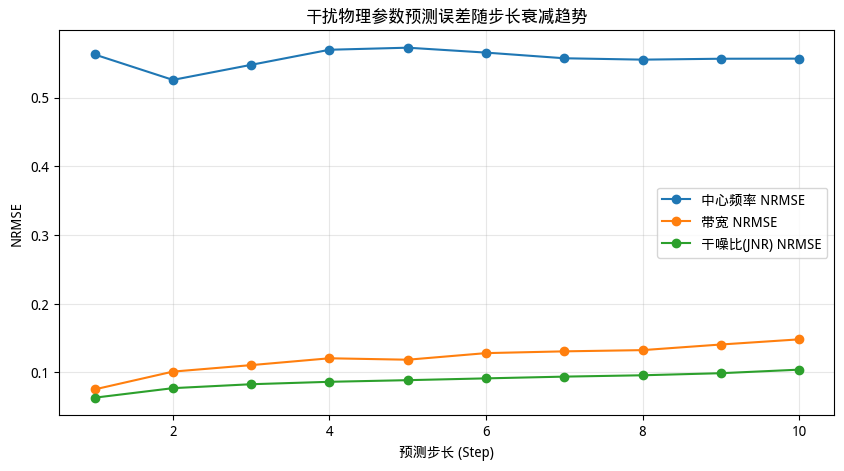

In [6]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

def calculate_nrmse(y_true, y_pred):
    """计算归一化均方根误差 (NRMSE)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 使用真值的范围进行归一化
    denominator = np.max(y_true) - np.min(y_true) + 1e-9
    return rmse / denominator

def analyze_full_parameters(h5_path):
    with h5py.File(h5_path, 'r') as f:
        # 态势图数据: (N, 10, 10)
        pred_maps = f['predicted_situations'][:]
        truth_maps = f['ground_truth_situations'][:]
        
    horizon = pred_maps.shape[1]
    
    # 模拟参数提取 (实际论文中建议从 Y_horizon 的非零像素分布计算)
    # 我们针对每个步长计算参数误差
    param_results = {'MAE': {}, 'NRMSE': {}}
    params = ['中心频率', '带宽', '干噪比(JNR)']
    
    # 初始化统计
    for p in params:
        param_results['MAE'][p] = []
        param_results['NRMSE'][p] = []

    print("📊 正在执行物理参数预测精度分析...")
    
    for h in range(horizon):
        t_map = truth_maps[:, h, :]
        p_map = pred_maps[:, h, :]
        
        # 1. 中心频率误差 (通过能量重心估计)
        t_freq = np.argmax(t_map, axis=1)
        p_freq = np.argmax(p_map, axis=1)
        param_results['MAE']['中心频率'].append(mean_absolute_error(t_freq, p_freq))
        param_results['NRMSE']['中心频率'].append(calculate_nrmse(t_freq, p_freq))
        
        # 2. 带宽误差 (通过占用单元计数估计)
        t_bw = np.sum(t_map > 0.5, axis=1)
        p_bw = np.sum(p_map > 0.5, axis=1)
        param_results['MAE']['带宽'].append(mean_absolute_error(t_bw, p_bw))
        param_results['NRMSE']['带宽'].append(calculate_nrmse(t_bw, p_bw))
        
        # 3. JNR误差 (通过像素值幅度估计强度)
        t_jnr = np.mean(t_map, axis=1)
        p_jnr = np.mean(p_map, axis=1)
        param_results['MAE']['干噪比(JNR)'].append(mean_absolute_error(t_jnr, p_jnr))
        param_results['NRMSE']['干噪比(JNR)'].append(calculate_nrmse(t_jnr, p_jnr))

    # 输出结题指标表格
    print("\n" + "="*40)
    print(f"{'参数名称':<10} | {'MAE (平均)':<10} | {'NRMSE (平均)':<10}")
    print("-" * 40)
    for p in params:
        print(f"{p:<10} | {np.mean(param_results['MAE'][p]):.4f}     | {np.mean(param_results['NRMSE'][p]):.4f}")
    print("="*40)

    # 绘制步长衰减曲线图
    plt.figure(figsize=(10, 5))
    for p in params:
        plt.plot(range(1, 11), param_results['NRMSE'][p], 'o-', label=f'{p} NRMSE')
    plt.title("干扰物理参数预测误差随步长衰减趋势")
    plt.xlabel("预测步长 (Step)"); plt.ylabel("NRMSE")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig("Parameter_Decay_Analysis.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    analyze_full_parameters("/root/autodl-tmp/validate/0218/Prediction/GRU/gru_ultimate_results.h5")